# 3.4 Using dandelion to study the consensus light chains

Author: Xuezhu Sunny Wang, Xinyi Xiong

## Dataset 📊

- scRNA-seq object of plasma cells
- The matching scBCR-seq files

## Steps overview 📒
- Use dandelion to compute the VDJ characteristics and isotype (chain_status,Extra pair,Orphan VDJ,Orphan VJ,Single pair)
- Align the full amino acid of light chain in each clonotype
- Plot the alignment heatmap and consensus light chain sequence of the amyloid clone


In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
from scipy.io import mmread
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import Image
import scanpy as sc
import re
from types import SimpleNamespace 
import dandelion as ddl
from matplotlib import cm
from collections.abc import Sequence
from collections import Counter
from typing import Sequence
np.random.seed(14)


/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/dandelion/lib/python3.10/site-packages/airr/schema.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/dandelion/lib/python3.10/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)



In [2]:
# Step 1: read the mapping file
mapping = pd.read_csv("Sample-to-BCR_mapping.csv")

# Step 2: create dictionary to store vdj objects
vdj_dict = {}

# Step 3: iterate over rows in mapping file
for _, row in mapping.iterrows():
    sample_id = row["Sample_ID"]
    file_path = row["BCR_File_Path"]

    folder_location = os.path.dirname(file_path) + "/"

    # Load VDJ data
    vdj = ddl.read_10x_vdj(folder_location, filename_prefix="filtered")

    # Add prefix to ensure unique barcodes
    vdj.add_cell_prefix(f"{sample_id}_")

    vdj_dict[sample_id] = vdj

# Merge all objects into one
vdj_merged = ddl.concat(list(vdj_dict.values()))

# Example: inspect merged object
print(vdj_merged)


Dandelion class object with n_obs = 290737 and n_contigs = 456154
    data: 'cell_id', 'is_cell_10x', 'sequence_id', 'high_confidence_10x', 'sequence_length_10x', 'locus', 'v_call', 'd_call', 'j_call', 'c_call', 'complete_vdj', 'productive', 'fwr1_aa', 'fwr1', 'cdr1_aa', 'cdr1', 'fwr2_aa', 'fwr2', 'cdr2_aa', 'cdr2', 'fwr3_aa', 'fwr3', 'junction_aa', 'junction', 'fwr4_aa', 'fwr4', 'consensus_count', 'umi_count', 'clone_id', 'raw_consensus_id_10x', 'exact_subclonotype_id_10x', 'rearrangement_status', 'sequence', 'sequence_aa', 'vj_in_frame', 'cdr3_start', 'cdr3_end', 'fwr1_start', 'fwr1_end', 'cdr1_start', 'cdr1_end', 'fwr2_start', 'fwr2_end', 'cdr2_start', 'cdr2_end', 'fwr3_start', 'fwr3_end', 'fwr4_start', 'fwr4_end', 'filtered_10x', 'is_asm_cell_10x'
    metadata: 'clone_id', 'clone_id_by_size', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'd_call_VDJ', 'j_call_VDJ', 'v_call_VJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junct

In [3]:
# --- Load data
adata = sc.read_h5ad("counts_clean_modified.h5ad")  # used to be the plasma cell sample

# Replace "MM" with "HPCAL" in all cell barcodes
adata.obs_names = adata.obs_names.str.replace("MM", "HPCAL", regex=False)

vdj, adata = ddl.pp.check_contigs(vdj_merged, adata)


Preparing data: 408696it [00:58, 6991.11it/s]
Scanning for poor quality/ambiguous contigs: 100%|██████████| 266127/266127 [09:36<00:00, 461.93it/s]


In [4]:
pd.crosstab(adata.obs["has_contig"], adata.obs["chain_status"])


chain_status,Extra pair,Orphan VDJ,Orphan VJ,Single pair
has_contig,,,,
True,2407,3242,75449,100736


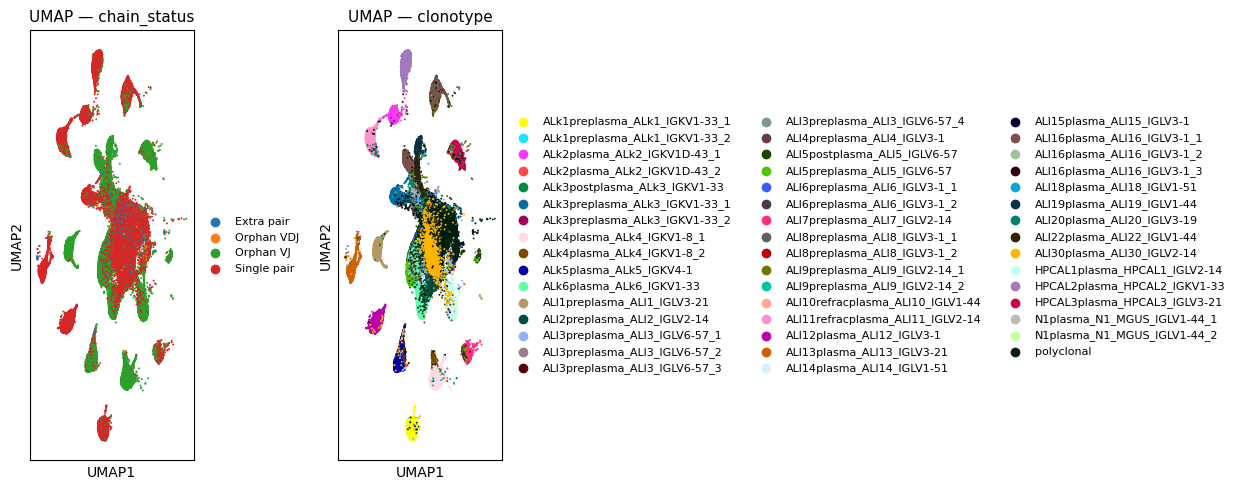

In [5]:
# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * figsize + figsize * wspace * (ncols - 1), nrows * figsize),
)
plt.subplots_adjust(wspace=wspace)

# --- Panel 1: clusters (leiden / seurat_clusters)
cluster_key = "chain_status" if "chain_status" in adata.obs.columns else "chain_status"
sc.pl.umap(
    adata,
    color=cluster_key,
    ax=axs[0],
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,            # tweak point size as you like
)
axs[0].set_title(f"UMAP — {cluster_key}", fontsize=11)

# --- Panel 2: clonotype (categorical)

sc.pl.umap(
    adata,
    color="clonotype",
    ax=axs[1],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
)
axs[1].set_title("UMAP — clonotype", fontsize=11)

# Optional: tighten layout, save, and show
plt.tight_layout()
plt.savefig("umap_clusters_clonotype.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
def run_clone_calling_with_regions(vdj, regions: Sequence[str], *, clone_key="clone_id"):
    """
    Combine multiple AA regions (e.g., ['fwr1_aa','cdr1_aa','junction_aa'])
    into one sequence string per contig and run ddl.tl.find_clones on it.
    Works for a Dandelion object (`vdj`) or a pandas DataFrame (returns a DF).
    """
    # Accept both Dandelion and plain DataFrame
    is_dandelion = hasattr(vdj, "data")
    table = vdj.data if is_dandelion else vdj.copy()

    # Keep only existing region columns (AA fields)
    cols = [c for c in regions if c in table.columns]
    if not cols:
        raise ValueError(f"None of {regions} present. Available columns include: {list(table.columns)[:30]} ...")

    # Build the combined AA key (uppercase, missing -> "")
    combo_col = "aa_combo"
    table[combo_col] = (
        table[cols]
        .astype(str)
        .replace({"nan": ""})
        .apply(lambda row: "".join(s.strip().upper() for s in row), axis=1)
    )

    # Push back to vdj if needed (preserve the same index order)
    if is_dandelion:
        vdj.data.loc[table.index, combo_col] = table[combo_col].values
    else:
        # If only a DataFrame was given, return with a 'clone_id' computed
        tmp = table.copy()
        # Minimal clone calling emulation: identical aa_combo => same label
        # (If you want the full Dandelion logic, pass a Dandelion object.)
        tmp[clone_key] = pd.factorize(tmp[combo_col])[0].astype(str)
        return tmp

    # (Optional) normalize V/J allele calls so *01/*02 don’t split clones
    try:
        vdj.simplify()
    except Exception:
        pass

    # IMPORTANT: Dandelion API expects 'key' for the sequence field and 'clone_key' for the output
    # Use your combined string column
    ddl.tl.find_clones(
        vdj,
        key=combo_col,          # <-- your concatenated AA column
        key_added=clone_key,    # <-- output column name
        # You can also pass v_call='v_call', j_call='j_call' if yours differ
    )

    return vdj

# EXAMPLE USE
regions_to_use = ["fwr1_aa","cdr1_aa","fwr2_aa","cdr2_aa","fwr3_aa","junction_aa","fwr4_aa"]
vdj = run_clone_calling_with_regions(vdj, regions_to_use, clone_key ="clone_id")


Finding clones based on B cell VJ chains : 100%|██████████| 289/289 [00:20<00:00, 14.24it/s]
Refining clone assignment based on VJ chain pairing : 100%|██████████| 181834/181834 [00:00<00:00, 369285.95it/s]


/tmp/ipykernel_4099065/877864880.py:17: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead


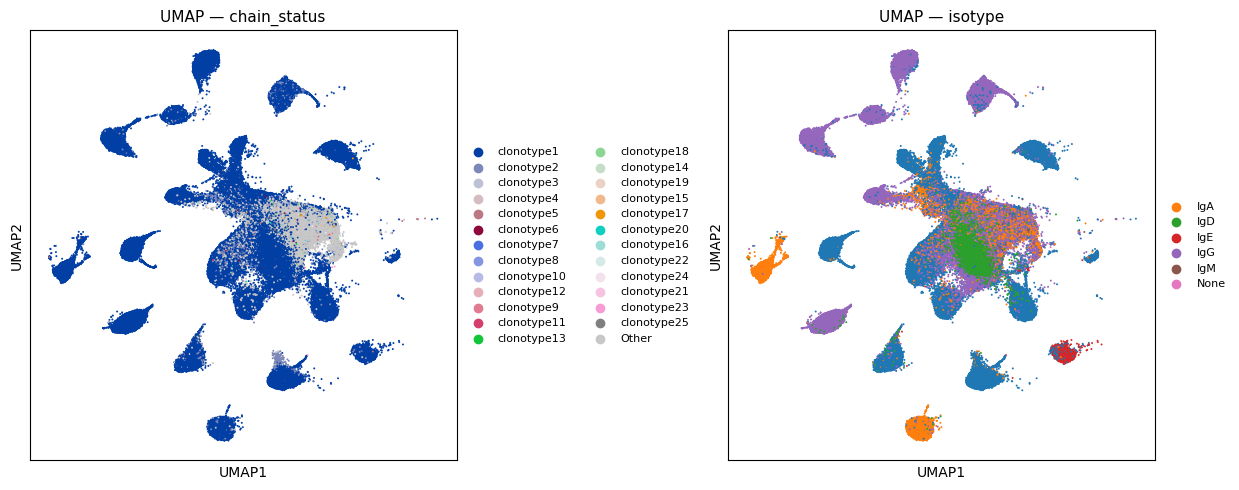

In [7]:
# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * figsize + figsize * wspace * (ncols - 1), nrows * figsize),
)
plt.subplots_adjust(wspace=wspace)

# --- Panel 1: clusters (leiden / seurat_clusters)
# 1) Start from a plain string Series (avoid categorical issues)
s = adata.obs["clone_id"]
if pd.api.types.is_categorical_dtype(s):
    s = s.astype(str)          # break out of Categorical
else:
    s = s.astype(str)

# 2) Top-20 and collapse others
top_clones = s.value_counts().head(25).index
simp = pd.Series(np.where(s.isin(top_clones), s, "Other"), index=s.index, dtype="object")

# 3) Make it categorical with an explicit category order (top 20 + "Other")
cats = list(top_clones) + ["Other"]
adata.obs["clone_id_simplified"] = pd.Categorical(simp, categories=cats, ordered=False)

# 4) (Optional) fix a palette so colors stay consistent; last color for "Other"
palette = sc.pl.palettes.default_20 + ["#BDBDBD"]  # grey for Other
adata.uns["clone_id_simplified_colors"] = palette[:len(cats)]

# 5) Plot (note: legend_loc *string* "none" to hide)
sc.pl.umap(
    adata,
    color="clone_id_simplified",
    ax=axs[0],
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
)


axs[0].set_title(f"UMAP — {cluster_key}", fontsize=11)

# --- Panel 2: clonotype (categorical)

sc.pl.umap(
    adata,
    color="isotype",
    ax=axs[1],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
)
axs[1].set_title("UMAP — isotype", fontsize=11)

# Optional: tighten layout, save, and show
plt.tight_layout()
plt.savefig("umap_cloneid_isotype.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
ddl.tl.transfer(adata, vdj, expanded_only=True)
adata

AnnData object with n_obs × n_vars = 181834 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'clonotype', 'labeltreat', 'labelpart1', 'labelpart2', 'response', 'treatment', 'labelrep', 'has_contig', 'clone_id', 'clone_id_by_size', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'd_call_VDJ', 'j_call_VDJ', 'v_call_VJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'v_call_B_VDJ', 'd_call_B_VDJ', 'j_call_B_VDJ', 'v_call_B_VJ', 'j_call_B_VJ', 'c_call_B_VDJ', 'c_call_B_VJ', 'productive_B_VDJ', 'productive_B_VJ', 'umi_count_B_VDJ', 'umi_count_B_VJ', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'v_call_B_VDJ_main', 'd_call_B_VDJ_main', 'j_call_B_V

In [9]:
# 1) Build the network on the downsampled VDJ
vdj_downsample =ddl.tl.generate_network(
    vdj,
    key="aa_combo",
    downsample=10000,
    compute_layout=True,
)


Setting up data: 15834it [00:01, 8114.89it/s]
Linking edges : 100%|██████████| 1748/1748 [00:10<00:00, 162.58it/s]


Computing network layout
Computing expanded network layout


In [10]:
# 2) Subset RNA expression AnnData to the *same* cells
keep = pd.Index(vdj_downsample.data.cell_id)
adata_downsample = adata[adata.obs_names.isin(keep)].copy()


In [11]:
ddl.tl.transfer(adata_downsample , vdj_downsample)

/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/dandelion/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp


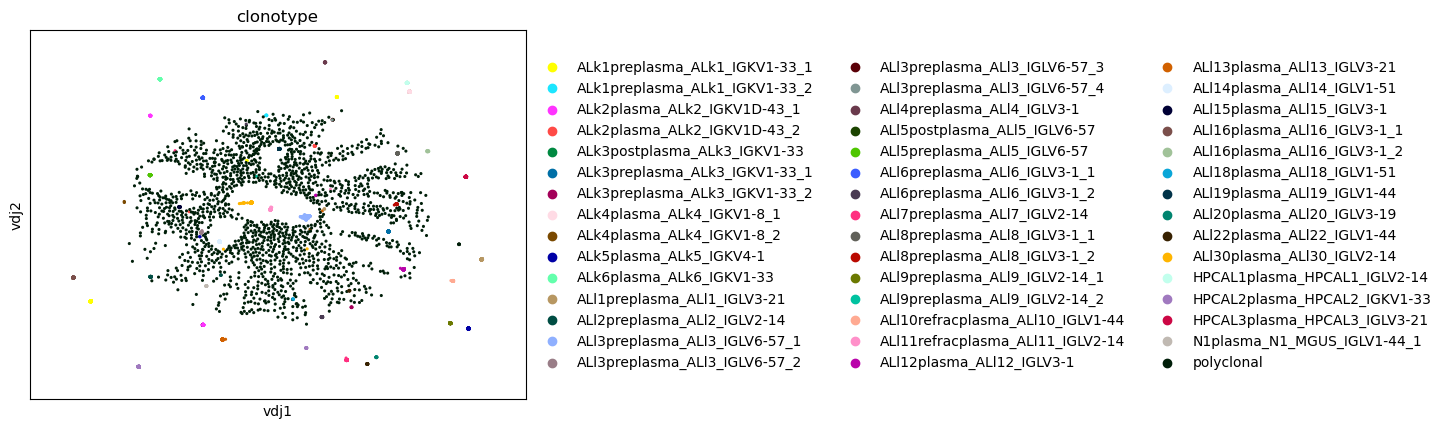

In [12]:
# --- Figure layout (2 panels side by side)
ncols = 1
nrows = 1
figsize = 3
wspace = 0.5

ddl.pl.clone_network(adata_downsample, color=["clonotype"], edges_width=1, size=20)

In [13]:
# Example: vdj.data is a DataFrame
df = vdj.data  # if vdj is a dandelion object

# extract the sample ID (everything before the first "_")
df["sample_id"] = df["sequence_id"].str.split("_", n=1).str[0]

# paste sample_id with raw_consensus_id_10x
df["sample_raw_consensus_id_10x"] = df["sample_id"] + "_" + df["raw_consensus_id_10x"]


In [14]:
# -*- coding: utf-8 -*-
import os, random, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# =========================
# Config — edit as needed
# =========================
SEED                = 14
OUTDIR              = "vdj_consensus_outputs_all"
SEQ_COL_CANDIDATES  = ["aa_combo"]
CLONOTYPE_COLS      = ["sample_raw_consensus_id_10x"]
CHAIN_COLS          = ["locus"]      # expect IGK/IGH/IGL
BARCODE_COLS        = ["cell_id"]
VALID_CHAINS        = {"IGK","IGH","IGL"}                    # keep only these
SAMPLE_N            = 50                                     # per (clonotype, chain) group
HEAT_FIG_DPI        = 200
HEAT_FIG_FMT        = "pdf"                                  # or "pdf"

random.seed(SEED)
np.random.seed(SEED)
os.makedirs(OUTDIR, exist_ok=True)

def _get_table(vdj):
    """Accept Dandelion object or pandas DataFrame and return a DataFrame."""
    return vdj.data if hasattr(vdj, "data") else vdj

def _first_existing(df, candidates, required=True, name_hint="column"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find a {name_hint}. Looked for: {candidates}")
    return None

def _pad_to_equal_length(seqs, pad="-"):
    max_len = max(len(s) for s in seqs)
    return [s + pad * (max_len - len(s)) for s in seqs], max_len

def _consensus_from_padded(padded_seqs, exclude={"-","X"}):
    """Return consensus string and per-position counts."""
    arr = np.array([list(s) for s in padded_seqs])  # shape: (N, L)
    L = arr.shape[1]
    cons = []
    pos_counts = []
    for j in range(L):
        col = arr[:, j]
        vals = [x for x in col if x not in exclude]
        if len(vals) == 0:
            cons.append("-")
            pos_counts.append({})
        else:
            cnt = Counter(vals)
            base, _ = cnt.most_common(1)[0]
            cons.append(base)
            pos_counts.append(cnt)
    return "".join(cons), pos_counts

def _match_matrix_vs_consensus(padded_seqs, consensus, match_val=1., mismatch_val=0., gap_val=-1.):
    """Return matrix (n_reads x L) with 1 (match), 0 (mismatch), -1 (gap)."""
    L = len(consensus)
    arr = np.array([list(s) for s in padded_seqs])
    cons_arr = np.array(list(consensus))[None, :].repeat(arr.shape[0], axis=0)
    is_gap = (arr == "-")
    is_match = (arr == cons_arr) & (~is_gap)
    mat = np.where(is_gap, gap_val, np.where(is_match, match_val, mismatch_val))
    return mat

def _shorten(ids, k=18):
    return [i if len(str(i)) <= k else (str(i)[:k-3] + "...") for i in ids]

def _save_heatmap_with_letters(match_mat, consensus, y_labels, seqs_padded, title, outpath, vmin=-1, vmax=1):
    """
    Heatmap (Spectral) of consensus match with AA letters drawn in each cell.
    match_mat: (n_reads x L), values in {-1,0,1}
    seqs_padded: list[str] AA (aligned) for each row
    """
    n, L = match_mat.shape
    plt.figure(figsize=(min(16, 0.12*L+4), max(6, 0.30*n+2)))
    im = plt.imshow(match_mat, aspect="auto", interpolation="nearest", cmap="Spectral", vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.03, pad=0.02, label="Consensus match (−1 gap, 0 mismatch, 1 match)")

    # y and x ticks
    plt.yticks(np.arange(n), _shorten(y_labels, k=22), fontsize=8)
    xticks = np.arange(0, L, max(1, L // 20))
    plt.xticks(xticks, xticks, fontsize=8)

    # letters in each cell (keep it legible; small font)
    for i in range(n):
        row_seq = seqs_padded[i]
        for j in range(L):
            aa = row_seq[j]
            # choose a single text color for legibility; black works on Spectral extremes reasonably
            plt.text(j, i, aa, ha="center", va="center", fontsize=6)

    # consensus letters above as a strip
    for j, aa in enumerate(consensus):
        if j % max(1, L // 120) == 0:
            plt.text(j, -0.6, aa, ha='center', va='center', fontsize=6)

    plt.title(title, fontsize=11, pad=10)
    plt.xlabel("Amino-acid position")
    plt.tight_layout()
    plt.savefig(outpath, dpi=HEAT_FIG_DPI, bbox_inches="tight", format=HEAT_FIG_FMT)
    plt.close()

def run_consensus_pipeline(vdj):
    df = _get_table(vdj).copy()

    seq_col   = _first_existing(df, SEQ_COL_CANDIDATES, name_hint="AA sequence column (e.g., 'combo.aa')")
    clono_col = _first_existing(df, CLONOTYPE_COLS, name_hint="clonotype column")
    chain_col = _first_existing(df, CHAIN_COLS, name_hint="chain column (IGK/IGH/IGL)")
    bc_col    = _first_existing(df, BARCODE_COLS, required=False)

    if bc_col is None:
        bc_col = "_row_id"
        df[bc_col] = [f"row{ix}" for ix in range(df.shape[0])]

    # keep IGK/IGH/IGL only and drop NA/empty sequences
    df = df[df[chain_col].isin(VALID_CHAINS)].copy()
    df = df[df[seq_col].astype(str).str.len() > 0].copy()

    consensus_rows = []
    fasta_all_rows = []     # FASTA-like: header, sequence (padded/aligned)
    fasta_samp_rows = []    # FASTA-like: header, sequence (padded/aligned)

    grouped = df.groupby([clono_col, chain_col], dropna=False)
    for (clono, chain), sub in grouped:
        seqs = sub[seq_col].astype(str).tolist()
        ids  = sub[bc_col].astype(str).tolist()

        # pad to equal length for position-wise consensus
        padded, L = _pad_to_equal_length(seqs, pad="-")
        consensus, _pos_counts = _consensus_from_padded(padded, exclude={"-","X"})

        # match matrix
        M = _match_matrix_vs_consensus(padded, consensus)  # n_reads x L
        # percent identity per read (excluding gaps in read)
        denom = (np.array([list(s) for s in padded]) != "-").sum(axis=1).clip(min=1)
        pid = (M == 1).sum(axis=1) / denom

        # record consensus (UNCHANGED table)
        consensus_rows.append({
            "clonotype": clono,
            "chain": chain,
            "length": L,
            "consensus_aa": consensus,
            "n_reads": len(seqs),
            "mean_pid": float(pid.mean())
        })

        # FASTA-like rows for ALL reads (aligned/padded)
        for rid, s in zip(ids, padded):
            header = f">{clono}|{chain}|{rid}"
            fasta_all_rows.append({"header": header, "sequence": s})

        # sample up to 50 reads; if <50 keep all
        idx = np.arange(len(seqs))
        if len(idx) > SAMPLE_N:
            idx = np.random.choice(idx, SAMPLE_N, replace=False)
        idx = list(idx)
        # order by similarity to make the plot prettier
        idx.sort(key=lambda i: -pid[i])

        sample_ids   = [ids[i] for i in idx]
        sample_mat   = M[idx, :]
        sample_seqs  = [padded[i] for i in idx]

        # FASTA-like rows for sampled reads (aligned/padded)
        for rid, s in zip(sample_ids, sample_seqs):
            header = f">{clono}|{chain}|{rid}"
            fasta_samp_rows.append({"header": header, "sequence": s})

        # === Plot ONLY if this group has >= 50 cells ===
        if len(seqs) >= 50:
            safe_clono = "".join(ch if ch in (string.ascii_letters+string.digits+"-_.") else "_" for ch in str(clono))
            title = f"Consensus match heatmap — clonotype {clono} | {chain} (n={len(seqs)}, showing {len(sample_ids)})"
            out_heat = os.path.join(OUTDIR, f"heatmap_{safe_clono}_{chain}.{HEAT_FIG_FMT}")
            _save_heatmap_with_letters(sample_mat, consensus, sample_ids, sample_seqs, title, out_heat)

    # write outputs
    consensus_df = pd.DataFrame(consensus_rows).sort_values(["chain","clonotype"])
    consensus_df.to_csv(os.path.join(OUTDIR, "consensus_by_clonotype_chain.tsv"), sep="\t", index=False)  # unchanged

    # FASTA-like TSVs (two columns: header, sequence) for ALL and SAMPLED50
    all_fa_df = pd.DataFrame(fasta_all_rows)
    all_fa_df.to_csv(os.path.join(OUTDIR, "all_reads_vs_consensus.tsv"), sep="\t", index=False)

    samp_fa_df = pd.DataFrame(fasta_samp_rows)
    samp_fa_df.to_csv(os.path.join(OUTDIR, "sampled50_reads_vs_consensus.tsv"), sep="\t", index=False)

    print(
        "Done.\n"
        f" - Consensus table (unchanged): {os.path.join(OUTDIR, 'consensus_by_clonotype_chain.tsv')}\n"
        f" - All reads (FASTA-like TSV):  {os.path.join(OUTDIR, 'all_reads_vs_consensus.tsv')}\n"
        f" - Sampled 50 (FASTA-like TSV): {os.path.join(OUTDIR, 'sampled50_reads_vs_consensus.tsv')}\n"
        f" - Heatmaps saved only for groups with ≥50 cells in: {OUTDIR}"
    )
# ===== Run it =====
run_consensus_pipeline(vdj)     # if vdj is a Dandelion object

In [3]:
# -*- coding: utf-8 -*-
import os
import string
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# -----------------------------
# Alignment / consensus helpers
# -----------------------------
def _pad_to_equal_length(seqs: List[str], pad: str = "-") -> Tuple[List[str], int]:
    """Pad all sequences to the maximum length with `pad` and return (padded_seqs, max_len)."""
    if not seqs:
        return [], 0
    max_len = max(len(s) for s in seqs)
    return [s + pad * (max_len - len(s)) for s in seqs], max_len


def _consensus_from_padded(
    padded_seqs: List[str], exclude: set = {"-", "X"}
) -> Tuple[str, List[Counter]]:
    """
    Compute column-wise consensus from equally long strings.
    Returns (consensus_string, per_position_counts).
    """
    if not padded_seqs:
        return "", []

    arr = np.array([list(s) for s in padded_seqs])  # (N, L)
    L = arr.shape[1]
    cons = []
    pos_counts = []
    for j in range(L):
        col = arr[:, j]
        vals = [x for x in col if x not in exclude]
        if len(vals) == 0:
            cons.append("-")
            pos_counts.append(Counter())
        else:
            cnt = Counter(vals)
            cons.append(cnt.most_common(1)[0][0])
            pos_counts.append(cnt)
    return "".join(cons), pos_counts


def _match_matrix_vs_consensus(
    padded_seqs: List[str],
    consensus: str,
    match_val: float = 1.0,
    mismatch_val: float = 0.0,
    gap_val: float = -1.0,
) -> np.ndarray:
    """
    Build an (n_reads x L) matrix with:
      match_val for matches to consensus,
      mismatch_val for mismatches,
      gap_val where the read has a gap ('-').
    """
    if not padded_seqs or not consensus:
        return np.zeros((0, 0), dtype=float)

    arr = np.array([list(s) for s in padded_seqs])   # (N, L)
    cons_arr = np.array(list(consensus))[None, :].repeat(arr.shape[0], axis=0)
    is_gap = (arr == "-")
    is_match = (arr == cons_arr) & (~is_gap)
    mat = np.where(is_gap, gap_val, np.where(is_match, match_val, mismatch_val))
    return mat


def compute_alignment(
    seqs: List[str],
    ids: Optional[List[str]] = None,
    *,
    pad_char: str = "-",
    exclude_from_consensus: set = {"-", "X"},
    sort_by_similarity: bool = True,
) -> Dict:
    """
    Align AA strings by simple right-padding, compute consensus and match matrix.
    """
    if ids is None:
        ids = [f"read{i}" for i in range(len(seqs))]
    assert len(ids) == len(seqs), "ids and seqs must be the same length"

    padded, L = _pad_to_equal_length(seqs, pad=pad_char)
    consensus, _pos_counts = _consensus_from_padded(padded, exclude=exclude_from_consensus)
    M = _match_matrix_vs_consensus(padded, consensus)

    # percent identity per read (excluding gaps in the read)
    arr = np.array([list(s) for s in padded])
    denom = (arr != pad_char).sum(axis=1).clip(min=1)
    pid = (M == 1).sum(axis=1) / denom

    order = list(range(len(seqs)))
    if sort_by_similarity:
        order.sort(key=lambda i: -pid[i])

    return {
        "padded": [padded[i] for i in order],
        "consensus": consensus,
        "match_matrix": M[order, :],
        "percent_id": pid[order],
        "order": order,
        "ids": [ids[i] for i in order],
        "length": L,
    }


# -----------------------------
# Heatmap plotting
# -----------------------------
def _shorten(ids: List[str], k: int = 22) -> List[str]:
    return [i if len(str(i)) <= k else (str(i)[: k - 3] + "...") for i in ids]


def plot_alignment_heatmap(
    match_mat: np.ndarray,
    consensus: str,
    row_labels: List[str],
    padded_seqs: List[str],
    *,
    title: str = "Consensus match heatmap",
    outpath: Optional[str] = None,
    vmin: float = -1.0,
    vmax: float = 1.0,
    dpi: int = 200,
    fig_format: str = "pdf",
):
    """
    Render a heatmap of match/mismatch/gap with AA letters in each cell and a consensus strip.
    """
    n, L = match_mat.shape
    if n == 0 or L == 0:
        raise ValueError("Empty match matrix")

    plt.figure(figsize=(min(16, 0.12 * L + 4), max(6, 0.30 * n + 2)))
    im = plt.imshow(
        match_mat, aspect="auto", interpolation="nearest", cmap="Spectral", vmin=vmin, vmax=vmax
    )
    plt.colorbar(
        im,
        fraction=0.03,
        pad=0.02,
        label="Consensus match (−1 gap, 0 mismatch, 1 match)",
    )

    # ticks
    plt.yticks(np.arange(n), _shorten(row_labels, k=22), fontsize=8)
    xticks = np.arange(0, L, max(1, L // 20))
    plt.xticks(xticks, xticks, fontsize=8)

    # letters in each cell
    for i in range(n):
        row_seq = padded_seqs[i]
        for j in range(L):
            aa = row_seq[j]
            plt.text(j, i, aa, ha="center", va="center", fontsize=6)

    # consensus strip
    for j, aa in enumerate(consensus):
        if j % max(1, L // 120) == 0:
            plt.text(j, -0.6, aa, ha="center", va="center", fontsize=6)

    plt.title(title, fontsize=11, pad=10)
    plt.xlabel("Amino-acid position")
    plt.tight_layout()

    if outpath:
        os.makedirs(os.path.dirname(outpath) or ".", exist_ok=True)
        plt.savefig(outpath, dpi=dpi, bbox_inches="tight", format=fig_format)
        plt.close()
    else:
        plt.show()


# -----------------------------
# TSV → filter → align → plot
# -----------------------------
def run_from_tsv(
    tsv_file: str = "./vdj_consensus_outputs_all/consensus_by_clonotype_chain.tsv",
    *,
    n_reads_cutoff: int = 100,         # keep rows with n_reads >= this
    max_rows: Optional[int] = 120,     # None = keep all after filtering; else take top-N by n_reads
    chain_keep: Optional[List[str]] = None,  # e.g., ["IGH","IGK","IGL"]; None = keep all
    outfig: Optional[str] = "./vdj_consensus_outputs_all/consensus_alignment_heatmap.pdf",
    fig_dpi: int = 200,
):
    # 1) Read and sanity-check
    df = pd.read_csv(tsv_file, sep="\t")
    required = {"consensus_aa", "n_reads"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in TSV: {missing}")

    # coerce and clean
    df = df.copy()
    df["n_reads"] = pd.to_numeric(df["n_reads"], errors="coerce")
    df = df.dropna(subset=["consensus_aa", "n_reads"])
    df["consensus_aa"] = df["consensus_aa"].astype(str)

    # optional chain filter (if a 'chain' column exists)
    if chain_keep is not None and "chain" in df.columns:
        df = df[df["chain"].isin(chain_keep)].copy()

    # 2) Filter by threshold and sort
    df = df[df["n_reads"] >= n_reads_cutoff].sort_values("n_reads", ascending=False)

    # 3) Optionally cap row count
    if max_rows is not None and len(df) > max_rows:
        df = df.head(max_rows).copy()

    if df.empty:
        raise ValueError("No rows passed the n_reads filter; try lowering n_reads_cutoff.")

    # 4) Build labels (robust to missing cols)
    def _safe(col, default=""):
        return df[col].astype(str) if col in df.columns else pd.Series([default] * len(df), index=df.index)

    # ID pattern: [clonotype]|[chain]  (n=reads)
    id_parts = []
    id_parts.append(_safe("clonotype", "clonotype?"))
    if "chain" in df.columns:
        id_parts.append(_safe("chain", "chain?"))
    row_ids = (id_parts[0] + "|" + (id_parts[1] if len(id_parts) > 1 else "")) if id_parts else _safe("id", "row")
    row_ids = (row_ids + " (n=" + df["n_reads"].astype(int).astype(str) + ")").tolist()

    seqs = df["consensus_aa"].tolist()

    # 5) Align and plot
    out = compute_alignment(seqs, row_ids, sort_by_similarity=True)
    title = f"Consensus AA vs reads ≥ {n_reads_cutoff} (rows={len(seqs)})"
    plot_alignment_heatmap(
        out["match_matrix"],
        out["consensus"],
        out["ids"],
        out["padded"],
        title=title,
        outpath=outfig,
        dpi=fig_dpi,
        fig_format=os.path.splitext(outfig)[1][1:] if outfig else "pdf",
    )
    return df  # return the filtered table in case you want to inspect downstream


# -----------------------------
# CLI-ish entry
# -----------------------------
if __name__ == "__main__":
    # Adjust these parameters as needed:
    _ = run_from_tsv(
        tsv_file="./vdj_consensus_outputs_all/consensus_by_clonotype_chain.tsv",
        n_reads_cutoff=500,         # <-- set your threshold here
        max_rows=120,               # set to None to keep all passing rows
        chain_keep=None,            # e.g., ["IGH","IGK","IGL"]
        outfig="./vdj_consensus_outputs_all/consensus_alignment_heatmap.pdf",
        fig_dpi=200,
    )
